# Earth Network Pruning Experiments

Test whether dense Earth drainage networks can be simplified to look more like sparse Martian valley networks by pruning insignificant tributaries using Strahler order gaps.

**Pruning strategy:**
1. Optionally remove low-order channels (`PRE_REMOVE_MAX_ORDER`).
2. At every confluence, compute `order_gap = receiving_order_at_confluence − tributary_branch_order`.
3. Prune the full upstream subtree of any tributary where `order_gap >= ORDER_GAP_TO_PRUNE`.

**Significant confluence ratio** — fraction of confluences where the downstream Strahler order *increases* (two equal-max-order branches merge). An insignificant confluence is one where a minor tributary joins without changing the main-channel order.

For **Mars valley networks** the ratio is computed by rooting each network at a leaf, running the rooted Horton-Strahler DFS, and comparing downstream vs. max-child orders at every junction. This gives a reference target for how "well-branched" the pruned Earth networks should look.

**Strategies tested:**

| Pre-removal | Order-gap threshold |
|---|---|
| None (0) | 2, 3, 4 |
| Remove 1st-order (1) | 2, 3, 4 |
| Remove 1st+2nd-order (2) | 2, 3, 4 |

## 0. Parameters

Edit these before running.

In [31]:
# ── Extraction threshold ──────────────────────────────────────────────────────
AREA_THRESHOLD_KM2 = 0.25   # Contributing-area threshold for stream extraction (km²)

# ── Pruning parameters ───────────────────────────────────────────────────────
# gap=2 is excluded: Mars complexity check (Section 5) shows it prunes Mars
# valley networks significantly, making it incompatible with Mars topology.
ORDER_GAP_TO_PRUNE   = 4   # Default for single-basin maps; use 3 or 4
PRE_REMOVE_MAX_ORDER = 2   # 1 = remove 1st-order  |  2 = remove 1st+2nd  |  3 = remove 1st–3rd

# ── Map example basin ────────────────────────────────────────────────────────
MAP_BASIN       = "inyo"   # Basin used for before/after and side-by-side maps
MAP_OUTLET_RANK = 0        # 0 = largest outlet basin in this DEM

# ── Multi-basin sweep (all available DEMs) ───────────────────────────────────
MAX_OUTLETS  = 40          # Cap per basin to keep runtime manageable
MIN_BASIN_PX = 500         # Skip trivially small basins

# ── Mars comparison ──────────────────────────────────────────────────────────
N_MARS_EXAMPLES = 3        # Number of Mars valley networks shown in comparison maps

# ── Output ───────────────────────────────────────────────────────────────────
EXPERIMENT_NAME = "earth_network_pruning"

## 1. Setup

In [32]:
from pathlib import Path
import os, sys, warnings

PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("CHANNEL_HEADS_ROOT", str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display, Markdown
import topotoolbox as tt3

from channel_heads.config import EXAMPLE_DEMS, RESULTS_DIR, get_experiment_output_dir
from channel_heads.basin_config import LOCAL_TO_PAPER_BASIN, get_basin_config
from channel_heads.dd_calibration import (
    MARS_DD_STATS,
    STATUS_OK,
    compute_pixel_size_m_from_dem,
    compute_threshold_cells,
    compute_stream_length_km,
    compute_convex_hull_area_km2,
    compute_basin_area_km2,
    linear_index_fortran,
    trim_to_min_order,
    mars_network_geometry,
    mars_network_table,
    _node_rowcol,
    _stream_segments_xy,
    _build_mars_adjacency,
    mask_boundary_xy,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

OUT_DIR = get_experiment_output_dir(EXPERIMENT_NAME)
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MARS_GPKG = PROJECT_ROOT / "data" / "final_valleys" / "final_valleys_fixed.gpkg"

C_EARTH   = "#1f6fb4"
C_PRUNED  = "#2e8b57"
C_MARS    = "#b5533f"
C_HULL    = "#c77c2f"
C_BASIN   = "#557f63"
C_GRAY    = "#606060"
C_REMOVED = "#cccccc"

_BARS = np.array([0.2, 0.5, 1, 2, 5, 10, 20, 50, 100])

BASINS_AVAILABLE = [n for n, p in EXAMPLE_DEMS.items() if p.exists()]
print(f"Project root  : {PROJECT_ROOT}")
print(f"Output dir    : {OUT_DIR}")
print(f"Earth DEMs    : {len(BASINS_AVAILABLE)} available — {BASINS_AVAILABLE}")
print(f"Mars GPKG     : {'found' if MARS_GPKG.exists() else 'NOT FOUND'}")

Project root  : /Users/guypi/Projects/channel-heads
Output dir    : /Users/guypi/Projects/channel-heads/data/results/experiments/earth_network_pruning
Earth DEMs    : 17 available — ['inyo', 'humboldt', 'calnalpine', 'daqing', 'luliang', 'kammanasie', 'finisterre', 'taiwan', 'panamint', 'sakhalin', 'vallefertil', 'sierramadre', 'sierranevadaspain', 'toano', 'troodos', 'tsugaru', 'yoro']
Mars GPKG     : found


## 2. Algorithm helpers

In [33]:
# ── Earth pruning ─────────────────────────────────────────────────────────────

def build_stream_graph(s):
    """Return (node_r, node_c, rc_to_id, in_edges) for a StreamObject.

    in_edges[i] = list of upstream node IDs flowing into node i
    (source_indices → target_indices == upstream → downstream).
    """
    node_r, node_c = _node_rowcol(s)
    n = len(node_r)
    rc_to_id = {(int(node_r[i]), int(node_c[i])): i for i in range(n)}
    src_r, src_c = s.source_indices
    tgt_r, tgt_c = s.target_indices
    in_edges = [[] for _ in range(n)]
    for sr, sc, tr, tc in zip(
        np.asarray(src_r), np.asarray(src_c),
        np.asarray(tgt_r), np.asarray(tgt_c),
    ):
        sid = rc_to_id.get((int(sr), int(sc)))
        tid = rc_to_id.get((int(tr), int(tc)))
        if sid is not None and tid is not None:
            in_edges[tid].append(sid)
    return node_r, node_c, rc_to_id, in_edges


def prune_by_order_gap(s, order_gap_to_prune):
    """Prune the entire upstream subtree of any tributary where
    receiving_order − tributary_order >= order_gap_to_prune.
    Returns a pruned StreamObject or None if everything is removed.
    """
    if s is None or order_gap_to_prune <= 0:
        return s
    strahler = np.asarray(s.streamorder(method="strahler"))
    node_r, node_c, rc_to_id, in_edges = build_stream_graph(s)
    n = len(node_r)
    pruned_roots = set()
    for node_id in range(n):
        upstream = in_edges[node_id]
        if len(upstream) < 2:
            continue
        receiving_order = int(strahler[node_id])
        for up_id in upstream:
            if receiving_order - int(strahler[up_id]) >= order_gap_to_prune:
                pruned_roots.add(up_id)
    if not pruned_roots:
        return s
    nodes_to_remove = set()
    for root in pruned_roots:
        stack = [root]
        while stack:
            curr = stack.pop()
            if curr in nodes_to_remove:
                continue
            nodes_to_remove.add(curr)
            for parent in in_edges[curr]:
                if parent not in nodes_to_remove:
                    stack.append(parent)
    keep = np.ones(n, dtype=bool)
    for nid in nodes_to_remove:
        keep[nid] = False
    return None if not keep.any() else s.subgraph(keep)


def apply_strategy(s, pre_remove_max_order, order_gap_to_prune):
    """Pre-remove low-order channels, then apply order-gap pruning."""
    if s is None:
        return None
    if pre_remove_max_order >= 1:
        s = trim_to_min_order(s, pre_remove_max_order + 1)
    return prune_by_order_gap(s, order_gap_to_prune)


def compute_confluence_metrics(s):
    """Return (n_total, n_significant, ratio).

    Significant = downstream Strahler order strictly greater than the
    maximum upstream tributary order (order increases at the junction).
    """
    if s is None:
        return 0, 0, float("nan")
    strahler = np.asarray(s.streamorder(method="strahler"))
    _, _, _, in_edges = build_stream_graph(s)
    total_conf = sig_conf = 0
    for node_id, upstream in enumerate(in_edges):
        if len(upstream) < 2:
            continue
        total_conf += 1
        if int(strahler[node_id]) > max(int(strahler[u]) for u in upstream):
            sig_conf += 1
    ratio = sig_conf / total_conf if total_conf > 0 else float("nan")
    return total_conf, sig_conf, ratio


def network_metrics(s, pixel_size_m):
    """Return (length_km, hull_area_km2, dd_hull)."""
    if s is None:
        return 0.0, float("nan"), float("nan")
    rows, cols = _node_rowcol(s)
    if rows.size == 0:
        return 0.0, float("nan"), float("nan")
    length_km = compute_stream_length_km(s, pixel_size_m)
    hull_km2, _, hstatus = compute_convex_hull_area_km2(
        rows.astype(float), cols.astype(float), pixel_size_m
    )
    dd_hull = length_km / hull_km2 if hstatus == STATUS_OK and hull_km2 > 0 else float("nan")
    return length_km, hull_km2, dd_hull


# ── Mars sig_conf_ratio ───────────────────────────────────────────────────────

def _rooted_strahler_and_conf(adj, root, component_nodes):
    """Root an undirected adjacency at `root`, run DFS, compute per-node
    Strahler orders, count confluences and significant confluences.

    Returns (s_order_dict, n_total_conf, n_sig_conf).
    """
    parent = {root: None}
    dfs_order = [root]
    visited = {root}
    stack = [root]
    while stack:
        u = stack.pop()
        for v in adj[u]:
            if v in visited or v not in component_nodes:
                continue
            visited.add(v)
            parent[v] = u
            dfs_order.append(v)
            stack.append(v)

    s_order = {}
    total_conf = sig_conf = 0
    for u in reversed(dfs_order):
        children = [v for v in adj[u] if parent.get(v) == u]
        if not children:
            s_order[u] = 1
            continue
        child_orders = [s_order[c] for c in children]
        mx = max(child_orders)
        node_order = mx + 1 if child_orders.count(mx) >= 2 else mx
        s_order[u] = node_order
        if len(children) >= 2:
            total_conf += 1
            if node_order > mx:
                sig_conf += 1

    return s_order, total_conf, sig_conf


def mars_sig_conf_ratio(lines):
    """Compute the significant confluence ratio for one Mars valley network.

    The network is undirected; we root each connected component at a leaf
    (degree-1 node) and apply the rooted Horton-Strahler rule. Returns
    (ratio, n_sig, n_total). Returns (nan, 0, 0) if no confluences exist.
    """
    adj = _build_mars_adjacency(lines)
    if not adj:
        return float("nan"), 0, 0

    # Find connected components
    seen = set()
    components = []
    for start in adj:
        if start in seen:
            continue
        comp = set()
        stack = [start]
        while stack:
            u = stack.pop()
            if u in seen:
                continue
            seen.add(u)
            comp.add(u)
            for v in adj[u]:
                if v not in seen:
                    stack.append(v)
        components.append(comp)

    total_conf = sig_conf = 0
    for comp in components:
        leaves = [n for n in comp if len(adj[n]) == 1]
        if not leaves:
            continue  # pure cycle — skip
        _, tc, sc = _rooted_strahler_and_conf(adj, leaves[0], comp)
        total_conf += tc
        sig_conf += sc

    ratio = sig_conf / total_conf if total_conf > 0 else float("nan")
    return ratio, sig_conf, total_conf


# ── Utilities ─────────────────────────────────────────────────────────────────

def strategy_label(pre_remove, gap, short=False):
    pre = {1: "Remove ≤1st", 2: "Remove ≤2nd", 3: "Remove ≤3rd"}[pre_remove]
    if short:
        pre = {1: "P≤1", 2: "P≤2", 3: "P≤3"}[pre_remove]
    return f"{pre}, gap≥{gap}"


def save_fig(fig, name, dpi=160):
    path = FIG_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved {path.name}")
    return path


# gap=2 excluded (incompatible with Mars topology — see Section 5).
# pre_remove=0 excluded; experiments start from removing at least 1st-order channels.
PRE_REMOVE_LEVELS = [1, 2, 3]
ORDER_GAP_LEVELS  = [3, 4]

print("Algorithm helpers defined.")

Algorithm helpers defined.


## 3. Drawing helpers

In [34]:
def geometry_bounds(*arrays):
    pts = []
    for arr in arrays:
        if arr is None:
            continue
        arr = np.asarray(arr)
        if arr.size:
            pts.append(arr.reshape(-1, 2))
    if not pts:
        return np.array([0.0, 0.0]), 1.0
    pts = np.vstack(pts)
    lo, hi = pts.min(axis=0), pts.max(axis=0)
    center = (lo + hi) / 2.0
    half = max(float((hi - lo).max()) / 2.0, 1.0) * 1.12
    return center, half


def _scale_bar(ax, hk):
    scale = _BARS[np.argmin(np.abs(_BARS - hk / 2.5))]
    x0, y0 = -hk * 0.88, -hk * 0.88
    ax.plot([x0, x0 + scale], [y0, y0], color="black", lw=2.0)
    ax.text(x0 + scale / 2, y0 + hk * 0.04, f"{scale:g} km",
            ha="center", va="bottom", fontsize=7)


def draw_earth_panel(ax, s, pixel_size_m, *,
                     s_removed=None, basin_boundary_xy=None,
                     outlet_xy=None, title="", center=None, half=None):
    segs    = None if s is None else _stream_segments_xy(s, pixel_size_m)
    rm_segs = None if s_removed is None else _stream_segments_xy(s_removed, pixel_size_m)
    all_pts = [
        segs, rm_segs, basin_boundary_xy,
        None if outlet_xy is None else np.array(outlet_xy).reshape(1, 2),
    ]
    if center is None or half is None:
        center, half = geometry_bounds(*all_pts)

    def tok(arr):
        return (np.asarray(arr) - center) / 1000.0

    if basin_boundary_xy is not None:
        b = tok(basin_boundary_xy)
        ax.plot(b[:, 0], b[:, 1], color=C_BASIN, lw=0.9, alpha=0.9)
    if rm_segs is not None and len(rm_segs):
        lw = float(np.clip(38.0 / np.sqrt(max(len(rm_segs), 1)), 0.15, 0.9))
        ax.add_collection(LineCollection(tok(rm_segs), colors=C_REMOVED, linewidths=lw))
    if segs is not None and len(segs):
        lw = float(np.clip(42.0 / np.sqrt(max(len(segs), 1)), 0.18, 1.1))
        ax.add_collection(LineCollection(tok(segs), colors=C_EARTH, linewidths=lw, alpha=0.95))
    if outlet_xy is not None:
        p = tok(np.asarray(outlet_xy).reshape(1, 2))[0]
        ax.scatter([p[0]], [p[1]], s=20, color="black", zorder=5)

    hk = half / 1000.0
    ax.set_xlim(-hk, hk); ax.set_ylim(-hk, hk)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=9, pad=4)
    _scale_bar(ax, hk)


def draw_mars_panel(ax, lines, hull_xy=None, title="", center=None, half=None):
    pts_flat = [np.asarray(line)[:, :2] for line in lines
                if np.asarray(line).shape[0] >= 2]
    if center is None or half is None:
        center, half = geometry_bounds(
            np.vstack(pts_flat) if pts_flat else None, hull_xy
        )

    def tok(arr):
        return (np.asarray(arr) - center) / 1000.0

    if pts_flat:
        lw = float(np.clip(12.0 / np.sqrt(max(len(pts_flat), 1)), 0.7, 1.8))
        ax.add_collection(LineCollection([tok(p) for p in pts_flat],
                                         colors=C_MARS, linewidths=lw, alpha=0.95))
    if hull_xy is not None and len(hull_xy):
        h = tok(np.vstack([hull_xy, hull_xy[:1]]))
        ax.plot(h[:, 0], h[:, 1], "--", color=C_HULL, lw=1.2)
        ax.fill(h[:, 0], h[:, 1], color=C_HULL, alpha=0.07)

    hk = half / 1000.0
    ax.set_xlim(-hk, hk); ax.set_ylim(-hk, hk)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=9, pad=4)
    _scale_bar(ax, hk)


print("Drawing helpers defined.")

Drawing helpers defined.


## 4. Mars significant confluence ratio

Compute the significant confluence ratio for every Mars valley network. This is the reference target: after pruning, Earth networks should approach this ratio.

Mars significant confluence ratio distribution:
  n       = 391
  median  = 0.375
  IQR     = [0.300, 0.571]
  mean    = 0.445

Interpretation:
  A ratio of 1.0 means every confluence in the network is between
  two equal-order branches (all junctions grow the order).
  A ratio near 0 means most junctions are minor tributaries joining
  a higher-order trunk without increasing the downstream order.
  Mars networks cluster near the median printed above — this is the
  target for the Earth pruning experiments.
saved fig_mars_sig_conf_ratio_distribution.png


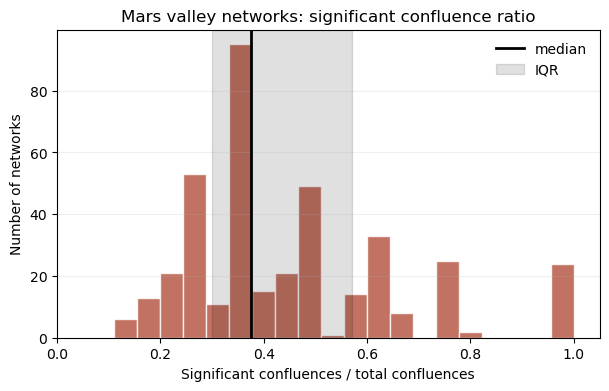

In [35]:
if not MARS_GPKG.exists():
    display(Markdown("**Mars GPKG not found — Mars sig_conf_ratio will not be computed.**"))
    MARS_SIG_RATIO_STATS = None
else:
    mars_geom  = mars_network_geometry(MARS_GPKG)
    mars_table = mars_network_table(MARS_GPKG)
    mars_ok    = mars_table[mars_table["status"] == STATUS_OK].copy()

    # Compute sig_conf_ratio for each valid network
    sig_ratios = []
    for nid in mars_ok["network_id"]:
        g = mars_geom.get(int(nid))
        if g is None or not g["lines"]:
            continue
        ratio, n_sig, n_tot = mars_sig_conf_ratio(g["lines"])
        if n_tot > 0:
            sig_ratios.append({"network_id": int(nid),
                               "sig_conf_ratio": ratio,
                               "n_sig": n_sig, "n_total": n_tot})

    mars_sig_df = pd.DataFrame(sig_ratios)
    vals = mars_sig_df["sig_conf_ratio"].dropna()

    MARS_SIG_RATIO_STATS = {
        "n":      len(vals),
        "median": float(vals.median()),
        "q1":     float(vals.quantile(0.25)),
        "q3":     float(vals.quantile(0.75)),
        "mean":   float(vals.mean()),
    }

    print("Mars significant confluence ratio distribution:")
    print(f"  n       = {MARS_SIG_RATIO_STATS['n']}")
    print(f"  median  = {MARS_SIG_RATIO_STATS['median']:.3f}")
    print(f"  IQR     = [{MARS_SIG_RATIO_STATS['q1']:.3f}, {MARS_SIG_RATIO_STATS['q3']:.3f}]")
    print(f"  mean    = {MARS_SIG_RATIO_STATS['mean']:.3f}")
    print()
    print("Interpretation:")
    print("  A ratio of 1.0 means every confluence in the network is between")
    print("  two equal-order branches (all junctions grow the order).")
    print("  A ratio near 0 means most junctions are minor tributaries joining")
    print("  a higher-order trunk without increasing the downstream order.")
    print("  Mars networks cluster near the median printed above — this is the")
    print("  target for the Earth pruning experiments.")

    # Distribution plot
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(vals, bins=20, color=C_MARS, alpha=0.82, edgecolor="white")
    ax.axvline(MARS_SIG_RATIO_STATS["median"], color="black", lw=2, label="median")
    ax.axvspan(MARS_SIG_RATIO_STATS["q1"], MARS_SIG_RATIO_STATS["q3"],
               color="black", alpha=0.12, label="IQR")
    ax.set_title("Mars valley networks: significant confluence ratio")
    ax.set_xlabel("Significant confluences / total confluences")
    ax.set_ylabel("Number of networks")
    ax.set_xlim(0, 1.05)
    ax.legend(frameon=False)
    ax.grid(True, axis="y", alpha=0.2)
    save_fig(fig, "fig_mars_sig_conf_ratio_distribution.png")
    plt.show()

## 5. Mars complexity check — how much would Mars be pruned?

Apply the same order-gap pruning algorithm to Mars mapped valley networks.
A gap setting that leaves Mars networks **mostly untouched** confirms it targets
the right structural complexity: Mars networks are already as simple as Earth
networks pruned to that gap.

For each gap threshold (2, 3, 4) and each Mars network the cell computes:
- **% of valley-network length that would be pruned**
- **% of Mars networks that survive completely untouched** (< 5% removed)

The gap at which ≥ 90% of Mars networks survive unpruned is the minimum
threshold compatible with Mars complexity.

Mars networks: % of valley-network length that would be pruned



,gap,n,% untouched (<5%),% heavily pruned (>30%),median % removed,q1 % removed,q3 % removed
0,3,391,98.5000,0.0000,0.0000,0.0000,0.0000
1,4,391,100.0000,0.0000,0.0000,0.0000,0.0000



  gap≥3: 98% untouched, median removed = 0.0%  ✓ COMPATIBLE
  gap≥4: 100% untouched, median removed = 0.0%  ✓ COMPATIBLE

  → Minimum gap compatible with Mars complexity: gap≥3
saved fig_mars_complexity_check.png


/var/folders/lq/1mmlyt8d7kg0w5y404p0l8j80000gn/T/ipykernel_90601/1853598289.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_gap, patch_artist=True,


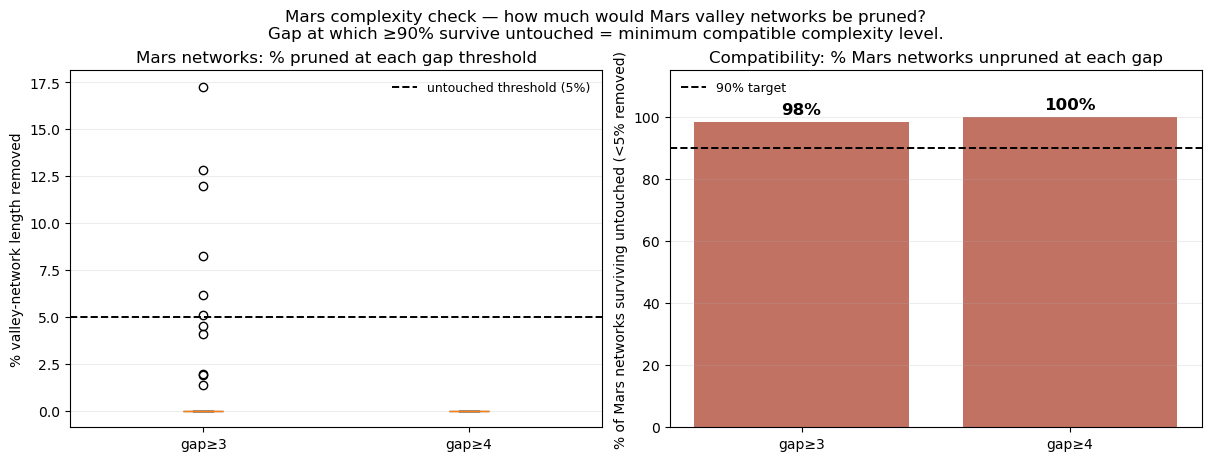

saved fig_mars_pruning_vs_dd_hull.png


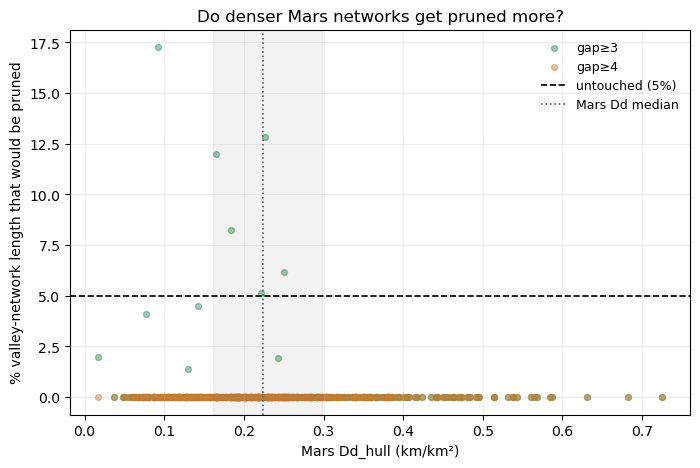

In [36]:
def simulate_mars_pruning_network(lines, order_gap_to_prune):
    """Simulate order-gap pruning on one Mars valley network.

    The network is undirected; each connected component is rooted at a leaf,
    Strahler orders are computed bottom-up, then tributary subtrees with
    receiving_order - tributary_order >= order_gap_to_prune are collected.

    Returns (pct_length_removed, n_pruned_confluences, n_total_confluences).
    Edge lengths use Euclidean distance between snapped graph vertices.
    """
    adj = _build_mars_adjacency(lines)
    if not adj:
        return float("nan"), 0, 0

    seen_global   = set()
    total_length  = 0.0
    removed_length = 0.0
    total_conf    = 0
    pruned_conf   = 0

    for start in list(adj):
        if start in seen_global:
            continue

        # find component
        comp = set()
        stk  = [start]
        while stk:
            u = stk.pop()
            if u in seen_global:
                continue
            seen_global.add(u)
            comp.add(u)
            for v in adj[u]:
                if v not in seen_global:
                    stk.append(v)

        leaves = [n for n in comp if len(adj[n]) == 1]

        # pure cycle: count length only
        if not leaves:
            seen_edges = set()
            for u in comp:
                for v in adj[u]:
                    e = (min(u, v), max(u, v))
                    if e not in seen_edges:
                        seen_edges.add(e)
                        dx, dy = v[0] - u[0], v[1] - u[1]
                        total_length += (dx * dx + dy * dy) ** 0.5
            continue

        root = leaves[0]

        # rooted DFS
        par     = {root: None}
        dfs_ord = [root]
        vis     = {root}
        stk     = [root]
        while stk:
            u = stk.pop()
            for v in adj[u]:
                if v not in vis and v in comp:
                    vis.add(v)
                    par[v] = u
                    dfs_ord.append(v)
                    stk.append(v)

        # Strahler orders bottom-up
        s_ord = {}
        for u in reversed(dfs_ord):
            children = [v for v in adj[u] if par.get(v) == u]
            if not children:
                s_ord[u] = 1
            else:
                co = [s_ord[c] for c in children]
                mx = max(co)
                s_ord[u] = mx + 1 if co.count(mx) >= 2 else mx

        # find pruned subtree roots
        pruned_roots = set()
        for u in dfs_ord:
            children = [v for v in adj[u] if par.get(v) == u]
            if len(children) < 2:
                continue
            total_conf += 1
            receiving   = s_ord[u]
            local_pruned = False
            for c in children:
                if receiving - s_ord[c] >= order_gap_to_prune:
                    pruned_roots.add(c)
                    local_pruned = True
            if local_pruned:
                pruned_conf += 1

        # collect all nodes in pruned subtrees
        nodes_removed = set()
        for pr in pruned_roots:
            stk = [pr]
            while stk:
                curr = stk.pop()
                if curr in nodes_removed:
                    continue
                nodes_removed.add(curr)
                for child in [v for v in adj[curr] if par.get(v) == curr]:
                    if child not in nodes_removed:
                        stk.append(child)

        # edge lengths
        seen_edges = set()
        for u in comp:
            for v in adj[u]:
                e = (min(u, v), max(u, v))
                if e in seen_edges:
                    continue
                seen_edges.add(e)
                dx, dy = v[0] - u[0], v[1] - u[1]
                elen    = (dx * dx + dy * dy) ** 0.5
                total_length += elen
                if u in nodes_removed or v in nodes_removed:
                    removed_length += elen

    pct_removed = 100.0 * removed_length / total_length if total_length > 0 else 0.0
    return pct_removed, pruned_conf, total_conf


# ── Run for all Mars networks × all gap thresholds ───────────────────────────
if not MARS_GPKG.exists():
    display(Markdown("**Mars GPKG not found — skipping Mars complexity check.**"))
    mars_prune_df = pd.DataFrame()
else:
    prune_rows = []
    for gap in ORDER_GAP_LEVELS:
        for row in mars_ok.itertuples(index=False):
            nid  = int(row.network_id)
            geom = mars_geom.get(nid)
            if geom is None or not geom["lines"]:
                continue
            pct_rem, n_pconf, n_tconf = simulate_mars_pruning_network(geom["lines"], gap)
            prune_rows.append({
                "network_id":           nid,
                "order_gap":            gap,
                "pct_length_removed":   pct_rem,
                "n_pruned_confluences": n_pconf,
                "n_total_confluences":  n_tconf,
                "dd_hull":              row.dd_hull_km_km2,
                "length_km":            row.length_km,
            })
    mars_prune_df = pd.DataFrame(prune_rows)

    # ── Summary table ─────────────────────────────────────────────────────────
    UNTOUCHED_PCT = 5.0   # < 5% removed → "untouched"

    mars_prune_sum_rows = []
    for gap in ORDER_GAP_LEVELS:
        sub = mars_prune_df[mars_prune_df["order_gap"] == gap]["pct_length_removed"].dropna()
        n   = len(sub)
        mars_prune_sum_rows.append({
            "order_gap":              gap,
            "n_networks":             n,
            "pct_untouched":          round(100.0 * (sub < UNTOUCHED_PCT).sum() / n, 1),
            "pct_heavily_pruned":     round(100.0 * (sub > 30).sum() / n, 1),
            "median_pct_removed":     round(float(sub.median()), 2),
            "q1_pct_removed":         round(float(sub.quantile(0.25)), 2),
            "q3_pct_removed":         round(float(sub.quantile(0.75)), 2),
        })
    mars_prune_summary = pd.DataFrame(mars_prune_sum_rows)
    mars_prune_summary.columns = [
        "gap", "n", "% untouched (<5%)", "% heavily pruned (>30%)",
        "median % removed", "q1 % removed", "q3 % removed",
    ]
    print("Mars networks: % of valley-network length that would be pruned\n")
    display(mars_prune_summary)
    print()
    compat_gap = None
    for _, row in mars_prune_summary.iterrows():
        flag = "✓ COMPATIBLE" if row["% untouched (<5%)"] >= 90 else ""
        print(
            f"  gap≥{int(row['gap'])}: "
            f"{row['% untouched (<5%)']:.0f}% untouched, "
            f"median removed = {row['median % removed']:.1f}%  {flag}"
        )
        if row["% untouched (<5%)"] >= 90 and compat_gap is None:
            compat_gap = int(row["gap"])
    print()
    if compat_gap is not None:
        print(f"  → Minimum gap compatible with Mars complexity: gap≥{compat_gap}")
    else:
        print("  → No tested gap leaves ≥90% of Mars networks untouched.")

    # ── Distribution plots ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

    ax = axes[0]
    data_by_gap = [
        mars_prune_df[mars_prune_df["order_gap"] == g]["pct_length_removed"].dropna().values
        for g in ORDER_GAP_LEVELS
    ]
    bp = ax.boxplot(data_by_gap, patch_artist=True,
                    labels=[f"gap≥{g}" for g in ORDER_GAP_LEVELS])
    for patch in bp["boxes"]:
        patch.set_facecolor(C_MARS)
        patch.set_alpha(0.6)
    ax.axhline(UNTOUCHED_PCT, color="black", ls="--", lw=1.4,
               label=f"untouched threshold ({UNTOUCHED_PCT:.0f}%)")
    ax.set_ylabel("% valley-network length removed")
    ax.set_title("Mars networks: % pruned at each gap threshold")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, axis="y", alpha=0.22)

    ax = axes[1]
    untouched_pcts = [row["% untouched (<5%)"] for _, row in mars_prune_summary.iterrows()]
    bars = ax.bar(
        [f"gap≥{g}" for g in ORDER_GAP_LEVELS],
        untouched_pcts,
        color=C_MARS, alpha=0.82,
    )
    for bar, val in zip(bars, untouched_pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{val:.0f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.axhline(90, color="black", ls="--", lw=1.4, label="90% target")
    ax.set_ylabel("% of Mars networks surviving untouched (<5% removed)")
    ax.set_title("Compatibility: % Mars networks unpruned at each gap")
    ax.set_ylim(0, 115)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, axis="y", alpha=0.22)

    fig.suptitle(
        "Mars complexity check — how much would Mars valley networks be pruned?\n"
        "Gap at which ≥90% survive untouched = minimum compatible complexity level.",
        fontsize=12,
    )
    save_fig(fig, "fig_mars_complexity_check.png")
    plt.show()

    # ── Scatter: % removed vs Dd_hull ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap_gaps = {2: C_EARTH, 3: C_PRUNED, 4: C_HULL}
    for gap in ORDER_GAP_LEVELS:
        sub = mars_prune_df[mars_prune_df["order_gap"] == gap].dropna(
            subset=["pct_length_removed", "dd_hull"]
        )
        ax.scatter(
            sub["dd_hull"], sub["pct_length_removed"],
            color=cmap_gaps[gap], alpha=0.45, s=18, label=f"gap≥{gap}",
        )
    ax.axhline(UNTOUCHED_PCT, color="black", ls="--", lw=1.2,
               label=f"untouched ({UNTOUCHED_PCT:.0f}%)")
    ax.axvspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"], color=C_GRAY, alpha=0.08)
    ax.axvline(MARS_DD_STATS["median"], color=C_GRAY, ls=":", lw=1.2, label="Mars Dd median")
    ax.set_xlabel("Mars Dd_hull (km/km\u00b2)")
    ax.set_ylabel("% valley-network length that would be pruned")
    ax.set_title("Do denser Mars networks get pruned more?")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.2)
    save_fig(fig, "fig_mars_pruning_vs_dd_hull.png")
    plt.show()


## 6. Load single-basin data for maps

In [37]:
cfg          = get_basin_config(LOCAL_TO_PAPER_BASIN.get(MAP_BASIN, MAP_BASIN))
dem_path     = EXAMPLE_DEMS[MAP_BASIN]
lat_deg      = float(cfg["lat"])
z_th         = cfg.get("z_th")

dem = tt3.read_tif(str(dem_path))
if z_th is not None:
    dem.z[dem.z < z_th] = np.nan

pixel_size_m    = compute_pixel_size_m_from_dem(dem, lat_deg=lat_deg)
threshold_cells = compute_threshold_cells(AREA_THRESHOLD_KM2, pixel_size_m)
fd  = tt3.FlowObject(dem)
s   = tt3.StreamObject(fd, threshold=threshold_cells)

n_rows      = dem.z.shape[0]
valid_dem   = ~np.isnan(dem.z)
outlet_ids  = np.flatnonzero(s.streampoi("outlets"))
node_r_all, node_c_all = _node_rowcol(s)

outlet_lin = np.array(
    [linear_index_fortran(node_r_all[o], node_c_all[o], n_rows) for o in outlet_ids],
    dtype=np.int64,
)
labels = np.asarray(fd.drainagebasins(outlet_lin).z)
sizes  = np.array([
    int(((labels == i + 1) & valid_dem).sum()) for i in range(len(outlet_ids))
])
rank_order = np.argsort(sizes)[::-1]
pick       = int(rank_order[min(MAP_OUTLET_RANK, len(rank_order) - 1)])
out_id     = int(outlet_ids[pick])

basin_mask    = (labels == pick + 1) & valid_dem
up_mask       = np.zeros(node_r_all.shape[0], dtype=bool)
up_mask[out_id] = True
s_up          = s.upstreamto(up_mask)
basin_area_km2 = compute_basin_area_km2(basin_mask, pixel_size_m)
basin_boundary = mask_boundary_xy(basin_mask, pixel_size_m)
outlet_xy      = np.array([
    node_c_all[out_id] * pixel_size_m,
    -node_r_all[out_id] * pixel_size_m,
], dtype=float)

len_full, hull_full, dd_full = network_metrics(s_up, pixel_size_m)
n_tot_f, n_sig_f, ratio_f   = compute_confluence_metrics(s_up)

print(f"Basin      : {MAP_BASIN} (outlet {out_id}, rank {MAP_OUTLET_RANK})")
print(f"Threshold  : {AREA_THRESHOLD_KM2} km² → {threshold_cells} cells")
print(f"Pixel size : {pixel_size_m:.1f} m")
print(f"Basin area : {basin_area_km2:.1f} km²")
print(f"Full network: L={len_full:.1f} km, Dd_hull={dd_full:.3f}, "
      f"sig.conf.ratio={ratio_f:.2f} ({n_sig_f}/{n_tot_f})")

Basin      : inyo (outlet 4285, rank 0)
Threshold  : 0.25 km² → 36 cells
Pixel size : 82.8 m
Basin area : 23.4 km²
Full network: L=28.7 km, Dd_hull=1.770, sig.conf.ratio=0.25 (6/24)


## 7. Before / after maps

Full network → pruned with the current parameters. Grey = removed channels.

saved fig_before_after.png


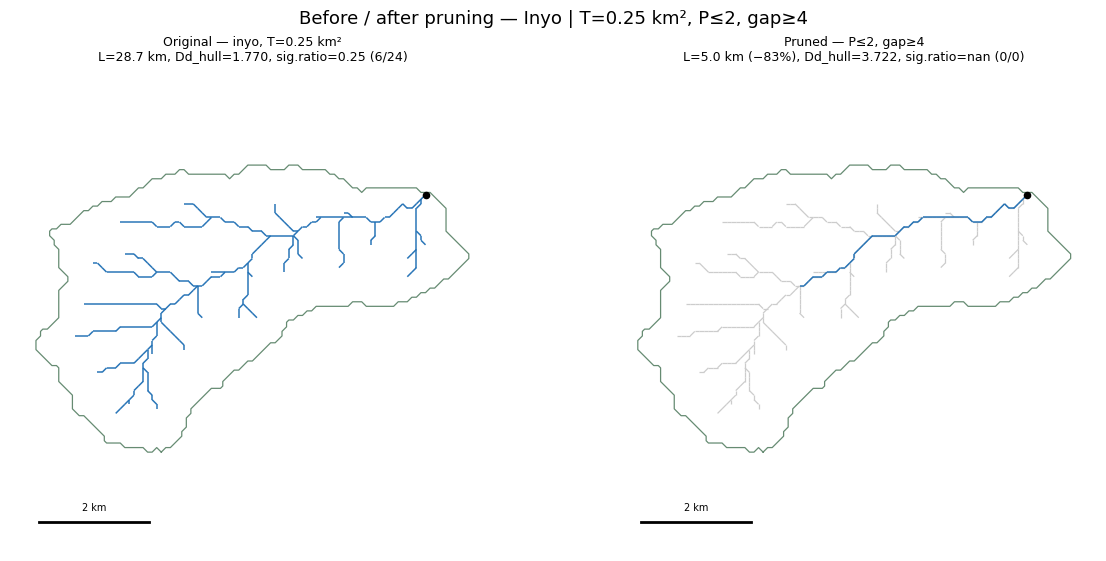

In [38]:
s_pruned = apply_strategy(s_up, PRE_REMOVE_MAX_ORDER, ORDER_GAP_TO_PRUNE)

len_p, hull_p, dd_p   = network_metrics(s_pruned, pixel_size_m)
n_tot_p, n_sig_p, ratio_p = compute_confluence_metrics(s_pruned)
pct_removed = 100.0 * (1.0 - len_p / len_full) if len_full > 0 else float("nan")

center, half = geometry_bounds(
    _stream_segments_xy(s_up, pixel_size_m), basin_boundary, outlet_xy.reshape(1, 2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
draw_earth_panel(
    axes[0], s_up, pixel_size_m,
    basin_boundary_xy=basin_boundary, outlet_xy=outlet_xy,
    title=(
        f"Original — {MAP_BASIN}, T={AREA_THRESHOLD_KM2:g} km²\n"
        f"L={len_full:.1f} km, Dd_hull={dd_full:.3f}, sig.ratio={ratio_f:.2f} ({n_sig_f}/{n_tot_f})"
    ),
    center=center, half=half,
)
draw_earth_panel(
    axes[1], s_pruned, pixel_size_m,
    s_removed=s_up,
    basin_boundary_xy=basin_boundary, outlet_xy=outlet_xy,
    title=(
        f"Pruned — P≤{PRE_REMOVE_MAX_ORDER}, gap≥{ORDER_GAP_TO_PRUNE}\n"
        f"L={len_p:.1f} km (−{pct_removed:.0f}%), Dd_hull={dd_p:.3f}, "
        f"sig.ratio={ratio_p:.2f} ({n_sig_p}/{n_tot_p})"
    ),
    center=center, half=half,
)
fig.suptitle(
    f"Before / after pruning — {MAP_BASIN.capitalize()}"
    f" | T={AREA_THRESHOLD_KM2:g} km², P≤{PRE_REMOVE_MAX_ORDER}, gap≥{ORDER_GAP_TO_PRUNE}",
    fontsize=13,
)
save_fig(fig, "fig_before_after.png")
plt.show()

## 8. Side-by-side comparison of all 9 strategies

Rows = pre-removal level (1, 2, 3). Columns = order-gap threshold (3, 4).

gap=2 excluded (incompatible with Mars topology — see Section 5).

saved fig_strategy_grid.png


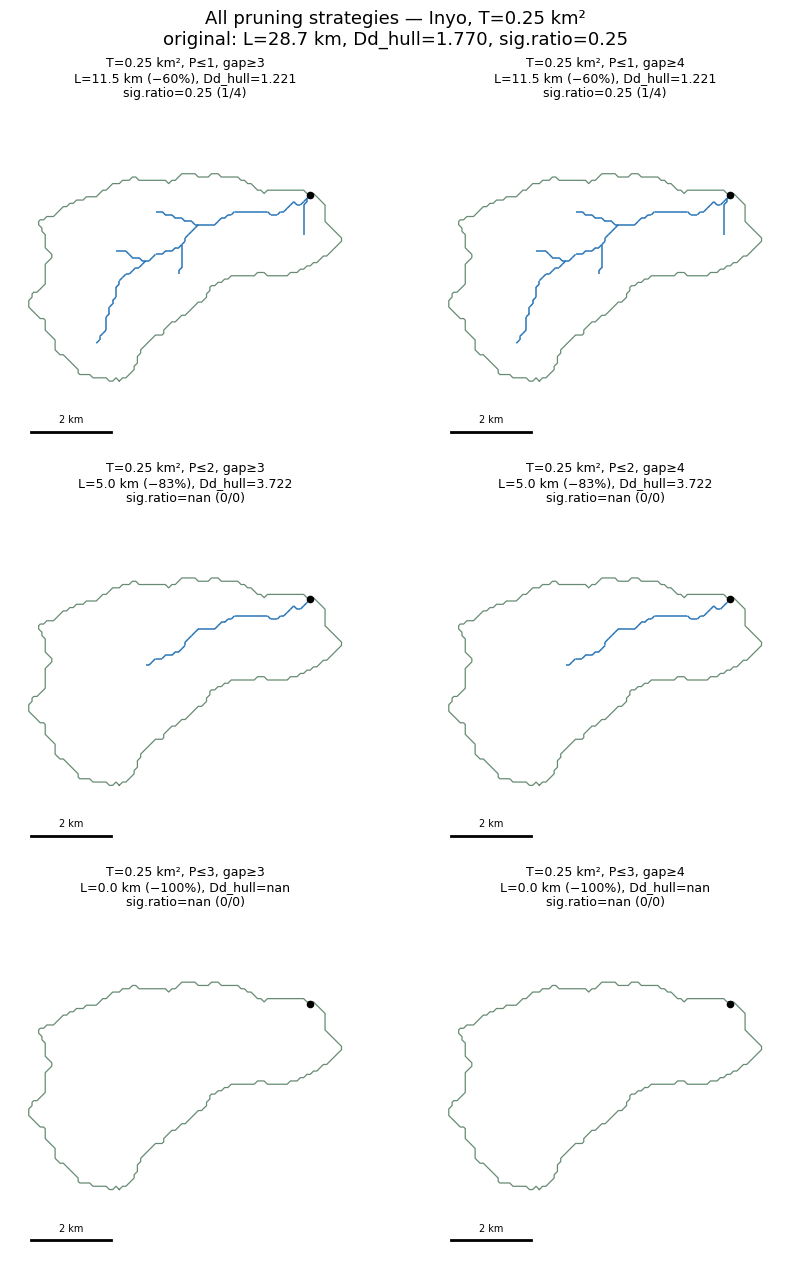

In [39]:
strategy_results = {}
for pre in PRE_REMOVE_LEVELS:
    for gap in ORDER_GAP_LEVELS:
        s_st = apply_strategy(s_up, pre, gap)
        lk, hk, dd = network_metrics(s_st, pixel_size_m)
        n_tot, n_sig, ratio = compute_confluence_metrics(s_st)
        pct = 100.0 * (1.0 - lk / len_full) if len_full > 0 else float("nan")
        strategy_results[(pre, gap)] = dict(
            s=s_st, length_km=lk, hull_km2=hk, dd_hull=dd,
            n_total_conf=n_tot, n_sig_conf=n_sig, sig_ratio=ratio, pct_removed=pct,
        )

fig, axes = plt.subplots(
    len(PRE_REMOVE_LEVELS), len(ORDER_GAP_LEVELS),
    figsize=(4.2 * len(ORDER_GAP_LEVELS), 4.2 * len(PRE_REMOVE_LEVELS)),
    constrained_layout=True,
)
for ri, pre in enumerate(PRE_REMOVE_LEVELS):
    for ci, gap in enumerate(ORDER_GAP_LEVELS):
        res = strategy_results[(pre, gap)]
        title = (
            f"T={AREA_THRESHOLD_KM2:g} km², P≤{pre}, gap≥{gap}\n"
            f"L={res['length_km']:.1f} km (−{res['pct_removed']:.0f}%), Dd_hull={res['dd_hull']:.3f}\n"
            f"sig.ratio={res['sig_ratio']:.2f} ({res['n_sig_conf']}/{res['n_total_conf']})"
        )
        draw_earth_panel(
            axes[ri][ci], res["s"], pixel_size_m,
            basin_boundary_xy=basin_boundary, outlet_xy=outlet_xy,
            title=title, center=center, half=half,
        )

fig.suptitle(
    f"All pruning strategies — {MAP_BASIN.capitalize()}, T={AREA_THRESHOLD_KM2:g} km²"
    f"\noriginal: L={len_full:.1f} km, Dd_hull={dd_full:.3f}, sig.ratio={ratio_f:.2f}",
    fontsize=13,
)
save_fig(fig, "fig_strategy_grid.png", dpi=140)
plt.show()

## 9. Mars comparison maps

Representative Mars valley networks beside Earth at three pruning settings.

saved fig_mars_earth_compare_net70.png


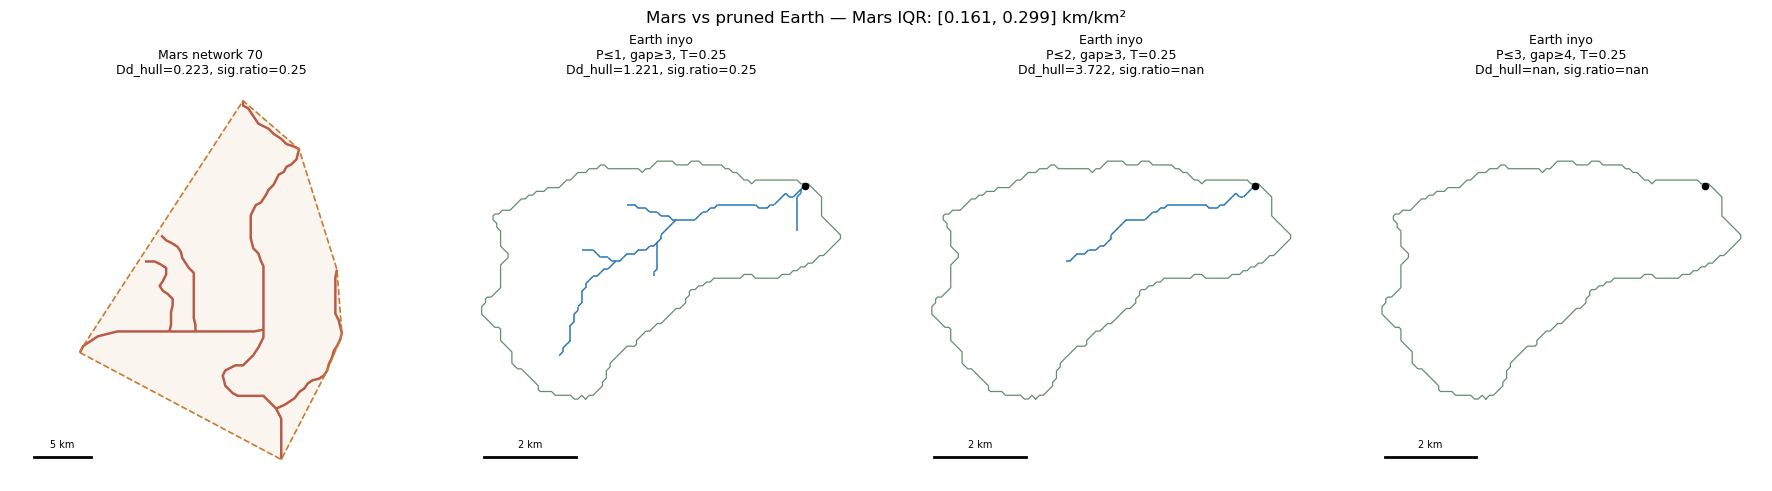

saved fig_mars_earth_compare_net66.png


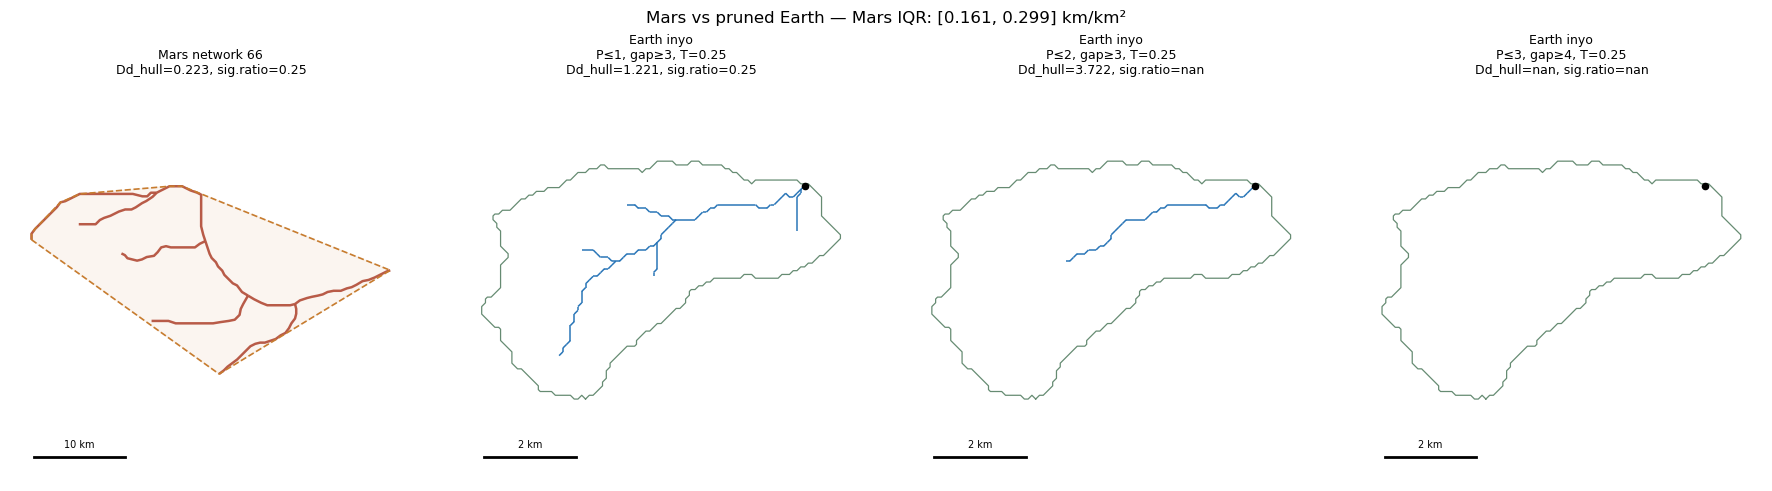

saved fig_mars_earth_compare_net354.png


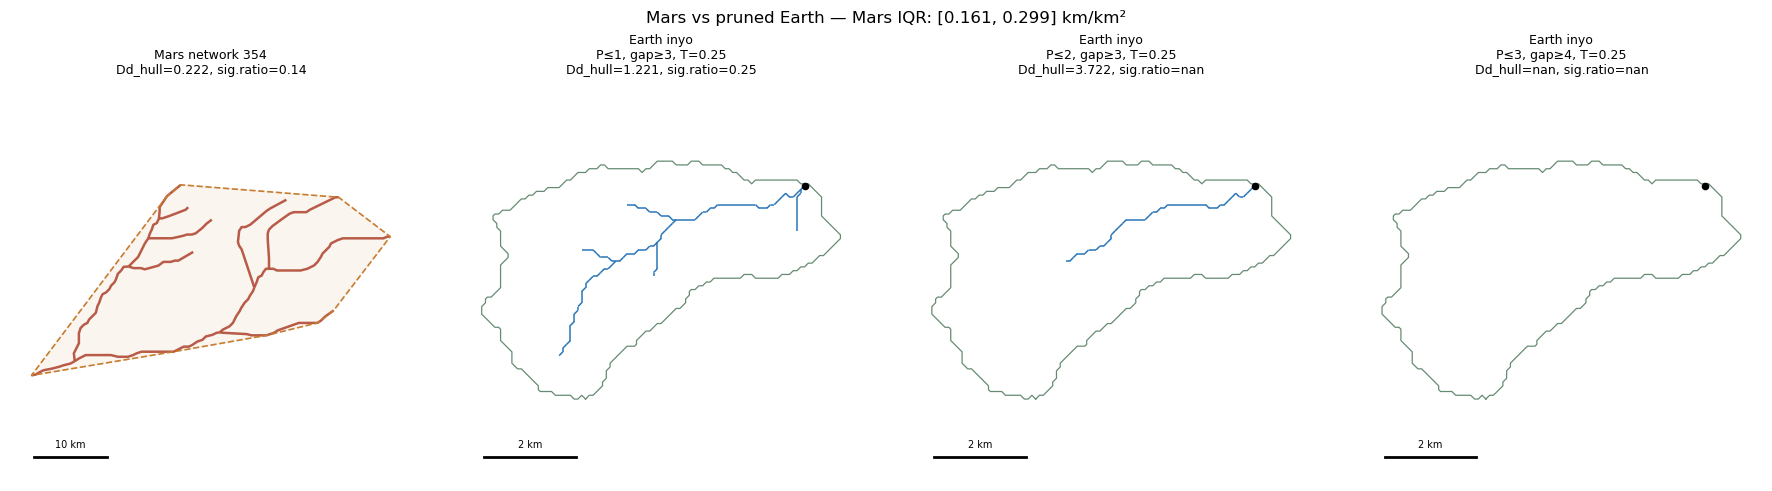

In [40]:
if not MARS_GPKG.exists():
    display(Markdown("**Mars GPKG not found — skipping Mars comparison maps.**"))
else:
    q1m, q3m, medm = MARS_DD_STATS["q1"], MARS_DD_STATS["q3"], MARS_DD_STATS["median"]
    pool = mars_ok[
        mars_ok["dd_hull_km_km2"].between(q1m, q3m)
        & (mars_ok["length_km"] >= mars_ok["length_km"].quantile(0.3))
    ].copy()
    if len(pool) < N_MARS_EXAMPLES:
        pool = mars_ok.copy()
    pool["_score"] = (pool["dd_hull_km_km2"] - medm).abs()
    selected_mars = pool.sort_values("_score").head(N_MARS_EXAMPLES)

    earth_compare = [(1, 3), (2, 3), (3, 4)]

    for row in selected_mars.itertuples(index=False):
        nid  = int(row.network_id)
        geom = mars_geom[nid]
        mr, ms, mt = mars_sig_conf_ratio(geom["lines"])
        sig_text = f", sig.ratio={mr:.2f}" if mt > 0 else ""

        n_cols = 1 + len(earth_compare)
        fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.8),
                                 constrained_layout=True)
        draw_mars_panel(
            axes[0], geom["lines"], hull_xy=geom["hull_xy"],
            title=f"Mars network {nid}\nDd_hull={row.dd_hull_km_km2:.3f}{sig_text}",
        )
        for ax, (pre, gap) in zip(axes[1:], earth_compare):
            res = strategy_results.get((pre, gap), {})
            draw_earth_panel(
                ax, res.get("s"), pixel_size_m,
                basin_boundary_xy=basin_boundary, outlet_xy=outlet_xy,
                title=(
                    f"Earth {MAP_BASIN}\n"
                    f"P≤{pre}, gap≥{gap}, T={AREA_THRESHOLD_KM2:g}\n"
                    f"Dd_hull={res.get('dd_hull', float('nan')):.3f}, "
                    f"sig.ratio={res.get('sig_ratio', float('nan')):.2f}"
                ),
                center=center, half=half,
            )
        fig.suptitle(
            f"Mars vs pruned Earth — Mars IQR: [{q1m:.3f}, {q3m:.3f}] km/km²",
            fontsize=12,
        )
        save_fig(fig, f"fig_mars_earth_compare_net{nid}.png", dpi=140)
        plt.show()

## 10. Multi-basin sweep — all available DEMs, saved per basin

Runs all 9 strategies on every available DEM. Results are saved individually to
`data/results/{basin}/pruning_sweep_{threshold}km2.csv`, then combined into
`data/results/experiments/earth_network_pruning/pruning_master.csv`.

In [41]:
THR_SLUG    = f"{AREA_THRESHOLD_KM2:g}km2".replace(".", "p")
MASTER_CSV  = OUT_DIR / "pruning_master.csv"

# ── Per-basin sweep ───────────────────────────────────────────────────────────
basin_dfs = []

for basin_name in BASINS_AVAILABLE:
    dem_p = EXAMPLE_DEMS.get(basin_name)
    if dem_p is None or not dem_p.exists():
        continue

    # Per-basin cache
    from channel_heads.config import get_output_dir
    basin_csv = get_output_dir(basin_name) / f"pruning_sweep_{THR_SLUG}.csv"
    if basin_csv.exists():
        print(f"  [{basin_name}] loading cache: {basin_csv.name}")
        basin_dfs.append(pd.read_csv(basin_csv))
        continue

    bcfg  = get_basin_config(LOCAL_TO_PAPER_BASIN.get(basin_name, basin_name))
    blat  = float(bcfg["lat"])
    bz_th = bcfg.get("z_th")

    bdem = tt3.read_tif(str(dem_p))
    if bz_th is not None:
        bdem.z[bdem.z < bz_th] = np.nan

    bpx     = compute_pixel_size_m_from_dem(bdem, lat_deg=blat)
    bcells  = compute_threshold_cells(AREA_THRESHOLD_KM2, bpx)
    bfd     = tt3.FlowObject(bdem)
    bs      = tt3.StreamObject(bfd, threshold=bcells)
    bvalid  = ~np.isnan(bdem.z)
    bn_rows = bdem.z.shape[0]

    bout_ids = np.flatnonzero(bs.streampoi("outlets"))
    if bout_ids.size == 0:
        print(f"  [{basin_name}] no outlets — skipping")
        continue

    bnr, bnc = _node_rowcol(bs)
    bout_lin = np.array(
        [linear_index_fortran(bnr[o], bnc[o], bn_rows) for o in bout_ids],
        dtype=np.int64,
    )
    blabels = np.asarray(bfd.drainagebasins(bout_lin).z)
    bsizes  = np.array([
        int(((blabels == i + 1) & bvalid).sum()) for i in range(len(bout_ids))
    ])

    keep_idx = np.flatnonzero(bsizes >= MIN_BASIN_PX)
    if MAX_OUTLETS is not None and len(keep_idx) > MAX_OUTLETS:
        keep_idx = keep_idx[np.argsort(bsizes[keep_idx])[::-1][:MAX_OUTLETS]]

    print(f"  [{basin_name}] {len(keep_idx)} basins × 9 strategies ...", flush=True)
    basin_rows = []

    for idx in keep_idx:
        boid   = int(bout_ids[idx])
        bmask  = (blabels == idx + 1) & bvalid
        bup_m  = np.zeros(bnr.shape[0], dtype=bool)
        bup_m[boid] = True
        bs_up  = bs.upstreamto(bup_m)

        barea        = compute_basin_area_km2(bmask, bpx)
        blen_f, bh_f, bdd_f = network_metrics(bs_up, bpx)
        bn_tf, bn_sf, brf   = compute_confluence_metrics(bs_up)

        for pre in PRE_REMOVE_LEVELS:
            for gap in ORDER_GAP_LEVELS:
                bs_st = apply_strategy(bs_up, pre, gap)
                blen_p, bh_p, bdd_p = network_metrics(bs_st, bpx)
                bn_tp, bn_sp, brp   = compute_confluence_metrics(bs_st)
                bpct = (
                    100.0 * (blen_f - blen_p) / blen_f
                    if blen_f > 0 else float("nan")
                )
                basin_rows.append({
                    "basin_name":            basin_name,
                    "outlet_node":           boid,
                    "basin_area_km2":        round(barea, 4),
                    "area_threshold_km2":    AREA_THRESHOLD_KM2,
                    "pre_remove_max_order":  pre,
                    "order_gap_threshold":   gap,
                    "orig_stream_length_km": round(blen_f, 4),
                    "pruned_stream_length_km": round(blen_p, 4),
                    "pct_length_removed":    round(bpct, 2),
                    "orig_dd_hull":          round(bdd_f, 5),
                    "pruned_dd_hull":        round(bdd_p, 5),
                    "orig_hull_area_km2":    round(bh_f, 4),
                    "pruned_hull_area_km2":  round(bh_p, 4),
                    "n_orig_confluences":    bn_tf,
                    "n_pruned_confluences":  bn_tp,
                    "orig_sig_conf_ratio":   round(brf, 4),
                    "pruned_sig_conf_ratio": round(brp, 4),
                })

    basin_df = pd.DataFrame(basin_rows)
    basin_df.to_csv(basin_csv, index=False)
    print(f"    → saved {basin_csv}")
    basin_dfs.append(basin_df)

# ── Combine into master ───────────────────────────────────────────────────────
sweep_df = pd.concat(basin_dfs, ignore_index=True) if basin_dfs else pd.DataFrame()
if not sweep_df.empty:
    sweep_df.to_csv(MASTER_CSV, index=False)
    print(f"\nMaster CSV: {MASTER_CSV} ({len(sweep_df)} rows, {sweep_df['basin_name'].nunique()} basins)")

display(sweep_df.head(9))

  [inyo] loading cache: pruning_sweep_0p25km2.csv
  [humboldt] loading cache: pruning_sweep_0p25km2.csv
  [calnalpine] loading cache: pruning_sweep_0p25km2.csv
  [daqing] loading cache: pruning_sweep_0p25km2.csv
  [luliang] loading cache: pruning_sweep_0p25km2.csv
  [kammanasie] loading cache: pruning_sweep_0p25km2.csv
  [finisterre] loading cache: pruning_sweep_0p25km2.csv
  [taiwan] loading cache: pruning_sweep_0p25km2.csv
  [panamint] loading cache: pruning_sweep_0p25km2.csv
  [sakhalin] loading cache: pruning_sweep_0p25km2.csv
  [vallefertil] loading cache: pruning_sweep_0p25km2.csv
  [sierramadre] loading cache: pruning_sweep_0p25km2.csv
  [sierranevadaspain] loading cache: pruning_sweep_0p25km2.csv
  [toano] loading cache: pruning_sweep_0p25km2.csv
  [troodos] loading cache: pruning_sweep_0p25km2.csv
  [tsugaru] loading cache: pruning_sweep_0p25km2.csv
  [yoro] loading cache: pruning_sweep_0p25km2.csv

Master CSV: /Users/guypi/Projects/channel-heads/data/results/experiments/earth

,basin_name,outlet_node,basin_area_km2,area_threshold_km2,pre_remove_max_order,order_gap_threshold,orig_stream_length_km,pruned_stream_length_km,pct_length_removed,orig_hull_area_km2,pruned_hull_area_km2,orig_dd_hull,pruned_dd_hull,n_orig_confluences,n_pruned_confluences,orig_sig_conf_ratio,pruned_sig_conf_ratio
0,inyo,8,6.4053,0.2500,0,2,11.3094,7.7670,31.3200,3.5075,2.3669,3.2244,3.2816,7,4,0.4286,0.7500
1,inyo,8,6.4053,0.2500,0,3,11.3094,11.3094,0.0000,3.5075,3.5075,3.2244,3.2244,7,7,0.4286,0.4286
2,inyo,8,6.4053,0.2500,0,4,11.3094,11.3094,0.0000,3.5075,3.5075,3.2244,3.2244,7,7,0.4286,0.4286
3,inyo,8,6.4053,0.2500,1,2,11.3094,3.7280,67.0400,3.5075,0.9659,3.2244,3.8595,7,1,0.4286,1.0000
4,inyo,8,6.4053,0.2500,1,3,11.3094,3.7280,67.0400,3.5075,0.9659,3.2244,3.8595,7,1,0.4286,1.0000
5,inyo,8,6.4053,0.2500,1,4,11.3094,3.7280,67.0400,3.5075,0.9659,3.2244,3.8595,7,1,0.4286,1.0000
6,inyo,8,6.4053,0.2500,2,2,11.3094,1.6813,85.1300,3.5075,0.1644,3.2244,10.2262,7,0,0.4286,NaN
7,inyo,8,6.4053,0.2500,2,3,11.3094,1.6813,85.1300,3.5075,0.1644,3.2244,10.2262,7,0,0.4286,NaN
8,inyo,8,6.4053,0.2500,2,4,11.3094,1.6813,85.1300,3.5075,0.1644,3.2244,10.2262,7,0,0.4286,NaN


## 11. Strategy summary plots

Median metrics across all basins and outlets for each strategy. Mars Dd_hull IQR and Mars sig_conf_ratio median are overlaid as reference targets.

In [42]:
# Filter to active strategies only (exclude cached rows from old runs with gap=2 or pre_remove=0).
active_sweep_df = sweep_df[
    sweep_df["pre_remove_max_order"].isin(PRE_REMOVE_LEVELS)
    & sweep_df["order_gap_threshold"].isin(ORDER_GAP_LEVELS)
]
summary_rows = []
for (pre, gap), grp in active_sweep_df.groupby(["pre_remove_max_order", "order_gap_threshold"]):
    dd  = grp["pruned_dd_hull"].replace([np.inf, -np.inf], np.nan).dropna()
    scr = grp["pruned_sig_conf_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    pct = grp["pct_length_removed"].replace([np.inf, -np.inf], np.nan).dropna()
    q1m, q3m = MARS_DD_STATS["q1"], MARS_DD_STATS["q3"]
    inside = float(100.0 * ((dd >= q1m) & (dd <= q3m)).mean()) if len(dd) else float("nan")
    summary_rows.append({
        "pre_remove":      int(pre),
        "order_gap":       int(gap),
        "label":           strategy_label(int(pre), int(gap), short=True),
        "n_networks":      len(grp),
        "med_dd_hull":     dd.median(),
        "q1_dd_hull":      dd.quantile(0.25),
        "q3_dd_hull":      dd.quantile(0.75),
        "med_sig_ratio":   scr.median(),
        "med_pct_removed": pct.median(),
        "pct_in_mars_iqr": inside,
    })
summary = pd.DataFrame(summary_rows)
display(summary[["label", "n_networks", "med_dd_hull",
                 "med_sig_ratio", "med_pct_removed", "pct_in_mars_iqr"]].round(3))

,label,n_networks,med_dd_hull,med_sig_ratio,med_pct_removed,pct_in_mars_iqr
0,"P≤1, gap≥3",524,1.6870,0.4290,51.4850,0.0000
1,"P≤1, gap≥4",524,1.6870,0.4000,50.6750,0.0000
2,"P≤2, gap≥3",524,1.9410,0.5000,79.2750,1.5500
3,"P≤2, gap≥4",524,1.9410,0.5000,79.1700,1.0340


saved fig_strategy_summary.png


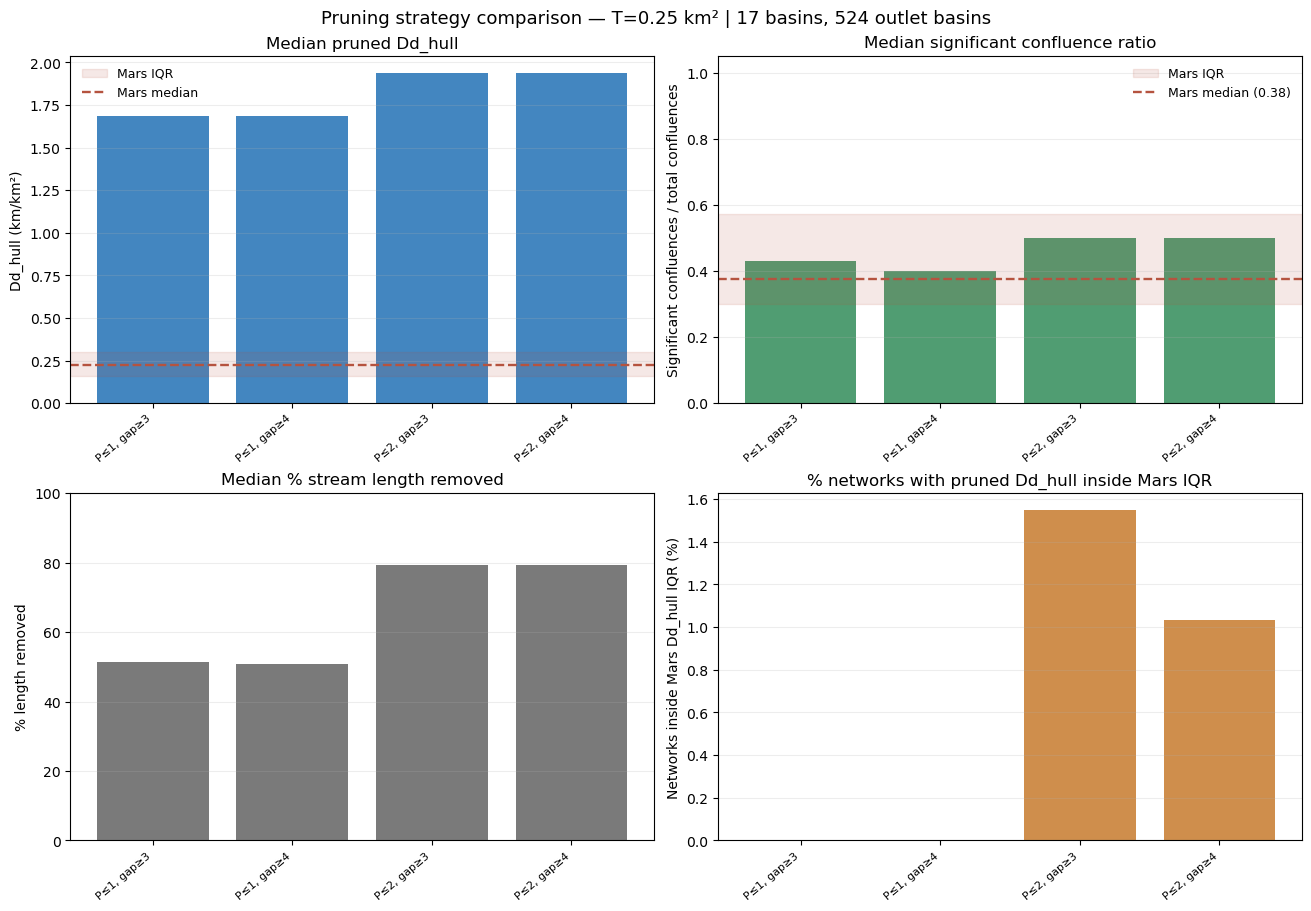

In [43]:
labels_all = summary["label"].tolist()
x          = np.arange(len(summary))

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

ax = axes[0, 0]
ax.bar(x, summary["med_dd_hull"], color=C_EARTH, alpha=0.84)
ax.axhspan(MARS_DD_STATS["q1"], MARS_DD_STATS["q3"], color=C_MARS, alpha=0.13, label="Mars IQR")
ax.axhline(MARS_DD_STATS["median"], color=C_MARS, ls="--", lw=1.7, label="Mars median")
ax.set_title("Median pruned Dd_hull")
ax.set_ylabel("Dd_hull (km/km²)")
ax.legend(frameon=False, fontsize=9)

ax = axes[0, 1]
ax.bar(x, summary["med_sig_ratio"], color=C_PRUNED, alpha=0.84)
if MARS_SIG_RATIO_STATS is not None:
    ax.axhspan(
        MARS_SIG_RATIO_STATS["q1"], MARS_SIG_RATIO_STATS["q3"],
        color=C_MARS, alpha=0.13, label="Mars IQR",
    )
    ax.axhline(MARS_SIG_RATIO_STATS["median"], color=C_MARS, ls="--", lw=1.7,
               label=f"Mars median ({MARS_SIG_RATIO_STATS['median']:.2f})")
    ax.legend(frameon=False, fontsize=9)
ax.set_title("Median significant confluence ratio")
ax.set_ylabel("Significant confluences / total confluences")
ax.set_ylim(0, 1.05)

ax = axes[1, 0]
ax.bar(x, summary["med_pct_removed"], color=C_GRAY, alpha=0.84)
ax.set_title("Median % stream length removed")
ax.set_ylabel("% length removed")
ax.set_ylim(0, 100)

ax = axes[1, 1]
ax.bar(x, summary["pct_in_mars_iqr"], color=C_HULL, alpha=0.86)
ax.set_title("% networks with pruned Dd_hull inside Mars IQR")
ax.set_ylabel("Networks inside Mars Dd_hull IQR (%)")

for ax in axes.ravel():
    ax.set_xticks(x)
    ax.set_xticklabels(labels_all, rotation=40, ha="right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.22)

fig.suptitle(
    f"Pruning strategy comparison — T={AREA_THRESHOLD_KM2:g} km²"
    f" | {sweep_df['basin_name'].nunique()} basins, {len(sweep_df) // 9} outlet basins",
    fontsize=13,
)
save_fig(fig, "fig_strategy_summary.png")
plt.show()

## 12. Recommendation

In [44]:
MARS_MED = MARS_DD_STATS["median"]
MARS_IQR_WIDTH = MARS_DD_STATS["iqr"]

summary = summary.copy()
summary["dd_dist_norm"] = (summary["med_dd_hull"] - MARS_MED).abs() / MARS_IQR_WIDTH
summary["over_prune_penalty"] = np.where(
    summary["med_pct_removed"] > 80,
    (summary["med_pct_removed"] - 80) / 20.0, 0.0
)

# If Mars sig_conf_ratio is available, score also by sig_ratio proximity
if MARS_SIG_RATIO_STATS is not None:
    mars_sig_med = MARS_SIG_RATIO_STATS["median"]
    summary["sig_ratio_dist"] = (summary["med_sig_ratio"] - mars_sig_med).abs()
else:
    summary["sig_ratio_dist"] = 0.0

# Strategies already filtered to gap∈{3,4} and pre_remove∈{1,2,3}.
# gap=2 is excluded: it significantly prunes Mars valley networks (Section 5)
# and is therefore structurally incompatible with the Mars complexity target.
summary["score"] = (
    summary["dd_dist_norm"]
    + 0.5 * summary["sig_ratio_dist"]
    - 0.2 * summary["pct_in_mars_iqr"] / 100.0
    + summary["over_prune_penalty"]
)

best    = summary.sort_values("score").iloc[0]
runners = summary.sort_values("score").iloc[1:3]

print("=" * 72)
print("RECOMMENDATION")
print("=" * 72)
print()
print(f"  Best strategy        : {best['label']}")
print(f"  Pre-remove max order : {int(best['pre_remove'])}")
print(f"  Order-gap threshold  : {int(best['order_gap'])}")
print(f"  Median Dd_hull       : {best['med_dd_hull']:.3f} km/km²  (Mars median {MARS_MED:.3f})")
print(f"  Median sig.conf.ratio: {best['med_sig_ratio']:.3f}", end="")
if MARS_SIG_RATIO_STATS is not None:
    print(f"  (Mars median {MARS_SIG_RATIO_STATS['median']:.3f})")
else:
    print()
print(f"  % inside Mars IQR    : {best['pct_in_mars_iqr']:.1f}%")
print(f"  Median length removed: {best['med_pct_removed']:.0f}%")
print()
print("Runner-up strategies:")
for _, row in runners.iterrows():
    print(f"  {row['label']:30s}  Dd_hull={row['med_dd_hull']:.3f}, "
          f"sig.ratio={row['med_sig_ratio']:.2f}, in_IQR={row['pct_in_mars_iqr']:.1f}%")
print()
print("Scope: gap ∈ {3, 4}  ×  pre-remove ∈ {1, 2, 3}")
print("gap=2 excluded: Mars complexity check (Section 5) showed it prunes")
print("Mars networks significantly → incompatible with Mars topology.")
print()
print("Score = Dd_hull distance (normalised by Mars IQR)")
print("      + 0.5 × |sig.conf.ratio − Mars sig.conf.ratio|")
print("      − 0.2 × fraction inside Mars Dd_hull IQR")
print("      + over-prune penalty (kicks in if > 80% removed)")
print("=" * 72)

RECOMMENDATION

  Best strategy        : P≤1, gap≥4
  Pre-remove max order : 1
  Order-gap threshold  : 4
  Median Dd_hull       : 1.687 km/km²  (Mars median 0.224)
  Median sig.conf.ratio: 0.400  (Mars median 0.375)
  % inside Mars IQR    : 0.0%
  Median length removed: 51%

Runner-up strategies:
  P≤1, gap≥3                      Dd_hull=1.687, sig.ratio=0.43, in_IQR=0.0%
  P≤2, gap≥3                      Dd_hull=1.941, sig.ratio=0.50, in_IQR=1.6%

Scope: gap ∈ {3, 4}  ×  pre-remove ∈ {1, 2, 3}
gap=2 excluded: Mars complexity check (Section 5) showed it prunes
Mars networks significantly → incompatible with Mars topology.

Score = Dd_hull distance (normalised by Mars IQR)
      + 0.5 × |sig.conf.ratio − Mars sig.conf.ratio|
      − 0.2 × fraction inside Mars Dd_hull IQR
      + over-prune penalty (kicks in if > 80% removed)
